In [ ]:
# Cell 1: Setup and Libraries
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ Libraries successfully loaded!")

✅ Libraries successfully loaded!


In [ ]:
# Cell 2: Load and Clean Dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
print("📥 Fetching real-world IBM Telco Churn dataset...")
df = pd.read_csv(url)

# Convert TotalCharges whitespace to float and impute 0 for tenure=0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Target binary encoding: Yes -> 1, No -> 0
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"📊 Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"📈 Churn Rate: {df['Churn_Numeric'].mean()*100:.2f}%")
df.head(5)

📥 Fetching real-world IBM Telco Churn dataset...
📊 Dataset Shape: 7043 rows, 22 columns
📈 Churn Rate: 26.54%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Numeric
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


/tmp/ipykernel_1150/3321793646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=['#2ca02c', '#d62728'])
/tmp/ipykernel_1150/3321793646.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1, 1], palette=['#2ca02c', '#d62728'])


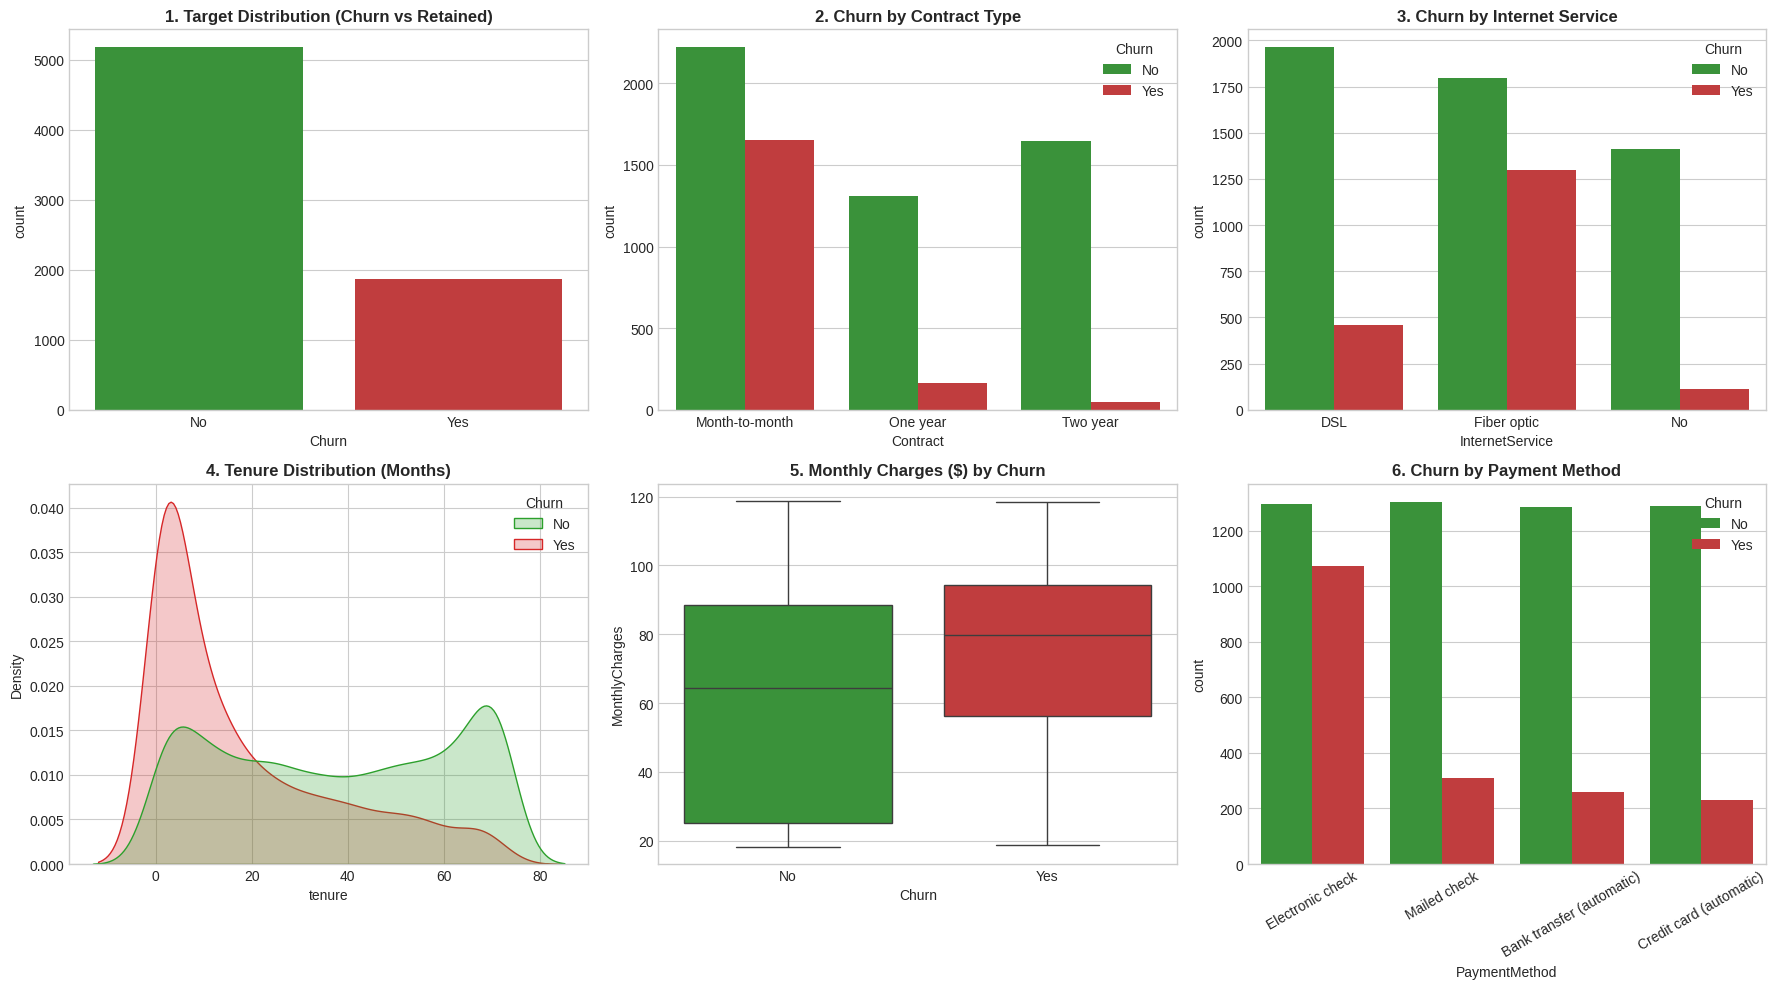

In [ ]:
# Cell 3: Exploratory Data Analysis Plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Target Distribution
sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=['#2ca02c', '#d62728'])
axes[0, 0].set_title('1. Target Distribution (Churn vs Retained)', fontweight='bold')

# 2. Churn by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0, 1], palette=['#2ca02c', '#d62728'])
axes[0, 1].set_title('2. Churn by Contract Type', fontweight='bold')

# 3. Churn by Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0, 2], palette=['#2ca02c', '#d62728'])
axes[0, 2].set_title('3. Churn by Internet Service', fontweight='bold')

# 4. Tenure Distribution
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, ax=axes[1, 0], palette=['#2ca02c', '#d62728'])
axes[1, 0].set_title('4. Tenure Distribution (Months)', fontweight='bold')

# 5. Monthly Charges Boxplot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1, 1], palette=['#2ca02c', '#d62728'])
axes[1, 1].set_title('5. Monthly Charges ($) by Churn', fontweight='bold')

# 6. Payment Method
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[1, 2], palette=['#2ca02c', '#d62728'])
axes[1, 2].set_title('6. Churn by Payment Method', fontweight='bold')
axes[1, 2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


--- 📊 MODEL COMPARISON RESULTS ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7452,0.5131,0.7834,0.6201,0.8468
1,Random Forest,0.7679,0.5441,0.7754,0.6395,0.8423
2,XGBoost,0.7828,0.6083,0.5107,0.5552,0.8221


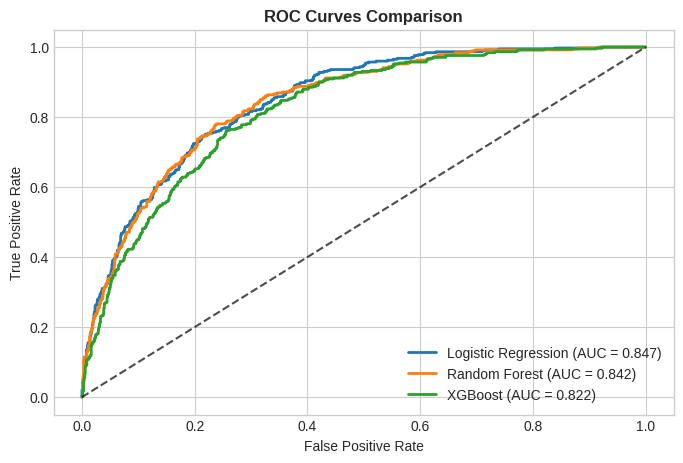

In [ ]:
# Cell 4: Feature Engineering, Preprocessing, and Training All Models

# Custom Transformer for Domain Features
class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.service_cols = [
            'PhoneService', 'MultipleLines', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies'
        ]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_out = X.copy()
        # 1. Total active services
        df_out['service_count'] = df_out.apply(
            lambda r: sum(1 for c in self.service_cols if c in r and r[c] == 'Yes'), axis=1
        )
        # 2. Tenure cohort bins
        bins = [-1, 12, 24, 48, 100]
        labels = ['0-12m', '13-24m', '25-48m', '49-72m']
        df_out['tenure_group'] = pd.cut(df_out['tenure'], bins=bins, labels=labels).astype(str)
        # 3. Spend metrics
        df_out['avg_monthly_charges'] = df_out['TotalCharges'] / (df_out['tenure'] + 1.0)
        df_out['monthly_to_total_ratio'] = df_out['MonthlyCharges'] / (df_out['TotalCharges'] + 1.0)
        # 4. Tech Support + Security bundle
        df_out['has_security_techsupport'] = (
            (df_out['OnlineSecurity'] == 'Yes') & (df_out['TechSupport'] == 'Yes')
        ).astype(int)
        return df_out

# Partition columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'service_count', 'avg_monthly_charges', 'monthly_to_total_ratio']
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group', 'has_security_techsupport'
]

# Pipeline Preprocessor (Prevents data leakage)
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))]), cat_cols)
])

# 80/20 Stratified Split
X = df.drop(columns=['customerID', 'Churn', 'Churn_Numeric'], errors='ignore')
y = df['Churn_Numeric']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Train Candidate Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

results = []
roc_curves = {}

for name, clf in models.items():
    pipe = Pipeline([
        ('fe', FeatureEngineeringTransformer()),
        ('prep', preprocessor),
        ('clf', clf)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'F1-Score': round(f1_score(y_test, preds), 4),
        'ROC-AUC': round(roc_auc_score(y_test, probs), 4)
    })
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_curves[name] = (fpr, tpr, roc_auc_score(y_test, probs))

print("\n--- 📊 MODEL COMPARISON RESULTS ---")
comp_df = pd.DataFrame(results)
display(comp_df)

# Plot ROC Curves
plt.figure(figsize=(8, 5))
for name, (fpr, tpr, auc_score) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
plt.title('ROC Curves Comparison', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
# Cell 5: Tuning, Joblib Export, Reloading, and Retention Strategy

print("⚙️ Running 5-Fold Stratified GridSearchCV on XGBoost Pipeline...")
tune_pipe = Pipeline([
    ('fe', FeatureEngineeringTransformer()),
    ('prep', preprocessor),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42))
])

param_grid = {
    'clf__n_estimators': [100, 150],
    'clf__max_depth': [3, 4],
    'clf__learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(tune_pipe, param_grid, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

best_pipeline = grid.best_estimator_
print(f"⭐ Best Hyperparameters: {grid.best_params_}")
print(f"⭐ Best 5-Fold CV ROC-AUC: {grid.best_score_:.4f}")

# Save full pipeline using Joblib
os.makedirs("models", exist_ok=True)
joblib_file = "models/customer_churn_retention_pipeline.joblib"
joblib.dump(best_pipeline, joblib_file)
print(f"💾 Pipeline successfully saved to '{joblib_file}'.")

# Reload without retraining
reloaded_model = joblib.load(joblib_file)
print("🔄 Model successfully reloaded from disk with ZERO retraining required!")

# Retention Strategy Generator Function
def predict_and_recommend(customer_dict):
    df_cust = pd.DataFrame([customer_dict])
    prob = float(reloaded_model.predict_proba(df_cust)[0, 1])
    risk = "High" if prob >= 0.60 else "Medium" if prob >= 0.35 else "Low"

    actions = []
    if risk == "High":
        if "month-to-month" in str(customer_dict.get('Contract', '')).lower():
            actions.append("Offer 20% discount on 1-year contract lock-in with price freeze guarantee.")
        if str(customer_dict.get('TechSupport', '')).lower() == 'no':
            actions.append("Provide 6 months of complimentary 24/7 Priority Tech Support.")
        if str(customer_dict.get('OnlineSecurity', '')).lower() == 'no':
            actions.append("Enroll in free Cyber Security & Antivirus Protection suite.")
        if float(customer_dict.get('MonthlyCharges', 0)) > 70.0:
            actions.append("Recommend personalized value bundle with $15/mo loyalty credit.")
    elif risk == "Medium":
        actions.append("Schedule customer success satisfaction check-in and offer loyalty tier bonus.")
    else:
        actions.append("Standard engagement. Candidate for premium speed cross-sell.")

    print("\n" + "="*60)
    print("🎯 NEW CUSTOMER PREDICTION & RETENTION REPORT")
    print("="*60)
    print(f"Predicted Churn Probability : {prob*100:.2f}%")
    print(f"Assigned Risk Tier          : {risk.upper()} RISK")
    print("\nRecommended Interventions:")
    for a in actions:
        print(f"  ✓ {a}")
    print("="*60)

# Test on a new, unseen customer
new_customer_data = {
    'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No',
    'tenure': 2, 'PhoneService': 'Yes', 'MultipleLines': 'No',
    'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check', 'MonthlyCharges': 89.50, 'TotalCharges': 179.00
}

predict_and_recommend(new_customer_data)

⚙️ Running 5-Fold Stratified GridSearchCV on XGBoost Pipeline...
⭐ Best Hyperparameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100}
⭐ Best 5-Fold CV ROC-AUC: 0.8492
💾 Pipeline successfully saved to 'models/customer_churn_retention_pipeline.joblib'.
🔄 Model successfully reloaded from disk with ZERO retraining required!

🎯 NEW CUSTOMER PREDICTION & RETENTION REPORT
Predicted Churn Probability : 72.73%
Assigned Risk Tier          : HIGH RISK

Recommended Interventions:
  ✓ Offer 20% discount on 1-year contract lock-in with price freeze guarantee.
  ✓ Provide 6 months of complimentary 24/7 Priority Tech Support.
  ✓ Enroll in free Cyber Security & Antivirus Protection suite.
  ✓ Recommend personalized value bundle with $15/mo loyalty credit.


In [6]:
# @title 🎯 Interactive Customer Churn Predictor & Retention Advisor
# @markdown Fill in the customer details below and run this cell to see real-time prediction and retention advice:

Tenure_Months = 3 # @param {type:"slider", min:0, max:72, step:1}
Monthly_Charges = 85.5 # @param {type:"slider", min:15.0, max:120.0, step:0.5}
Contract = "Month-to-month" # @param ["Month-to-month", "One year", "Two year"]
Internet_Service = "Fiber optic" # @param ["DSL", "Fiber optic", "No"]
Tech_Support = "No" # @param ["Yes", "No", "No internet service"]
Online_Security = "No" # @param ["Yes", "No", "No internet service"]
Payment_Method = "Electronic check" # @param ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"]
Senior_Citizen = "No" # @param ["Yes", "No"]
Paperless_Billing = "Yes" # @param ["Yes", "No"]

# Build input dictionary
test_cust = {
    'gender': 'Female',
    'SeniorCitizen': 1 if Senior_Citizen == "Yes" else 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': Tenure_Months,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': Internet_Service,
    'OnlineSecurity': Online_Security,
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': Tech_Support,
    'StreamingTV': 'Yes',
    'StreamingMovies': 'No',
    'Contract': Contract,
    'PaperlessBilling': Paperless_Billing,
    'PaymentMethod': Payment_Method,
    'MonthlyCharges': Monthly_Charges,
    'TotalCharges': Tenure_Months * Monthly_Charges
}

# Run inference through reloaded pipeline
df_input = pd.DataFrame([test_cust])
churn_prob = float(reloaded_model.predict_proba(df_input)[0, 1])
risk_tier = "HIGH" if churn_prob >= 0.60 else "MEDIUM" if churn_prob >= 0.35 else "LOW"

# Generate strategic recommendations
recs = []
if risk_tier == "HIGH":
    if Contract == "Month-to-month":
        recs.append("Offer 20% discount on a 1-year contract lock-in with price freeze guarantee.")
    if Tech_Support == "No":
        recs.append("Provide 6 months of complimentary 24/7 Priority Tech Support.")
    if Online_Security == "No":
        recs.append("Enroll in free Cyber Security & Antivirus Protection suite.")
    if Monthly_Charges > 75.0:
        recs.append("Recommend personalized value bundle with $15/month loyalty credit.")
    if Payment_Method == "Electronic check":
        recs.append("Offer $10 account credit to switch from Electronic Check to Autopay.")
elif risk_tier == "MEDIUM":
    recs.append("Schedule customer success onboarding check-in call.")
    recs.append("Offer flexible semi-annual loyalty extension.")
else:
    recs.append("Account is healthy. Maintain standard communications and explore cross-sell opportunities.")

# Visual Display
print("=" * 65)
print("           CUSTOMER CHURN & RETENTION STRATEGY ADVISORY")
print("=" * 65)
print(f" Predicted Churn Probability : {churn_prob*100:.2f}%")
print(f" Risk Classification        : {risk_tier} RISK")
print("-" * 65)
print(" Recommended Business Retention Interventions:")
for r in recs:
    print(f"   ✓ {r}")
print("=" * 65)

           CUSTOMER CHURN & RETENTION STRATEGY ADVISORY
 Predicted Churn Probability : 69.07%
 Risk Classification        : HIGH RISK
-----------------------------------------------------------------
 Recommended Business Retention Interventions:
   ✓ Offer 20% discount on a 1-year contract lock-in with price freeze guarantee.
   ✓ Provide 6 months of complimentary 24/7 Priority Tech Support.
   ✓ Enroll in free Cyber Security & Antivirus Protection suite.
   ✓ Recommend personalized value bundle with $15/month loyalty credit.
   ✓ Offer $10 account credit to switch from Electronic Check to Autopay.


        EXECUTIVE REVENUE-AT-RISK ANALYSIS (TEST COHORT)
Total Portfolio Monthly Billing : $90,301.20
High-Risk Monthly Revenue at Risk: $12,730.35 (14.1%)
Estimated Annualized Exposure   : $152,764.20
High-Risk Customers             : 159 / 1409 (11.3%)


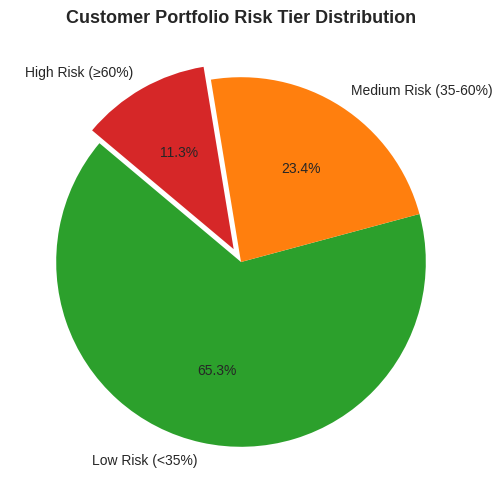

In [7]:
# Cell 7: Portfolio Business Metrics & Revenue-at-Risk Analysis

# Generate predictions for all test customers
X_test_df = X_test.copy()
test_probabilities = reloaded_model.predict_proba(X_test_df)[:, 1]

# Financial Calculations
high_risk_mask = test_probabilities >= 0.60
med_risk_mask = (test_probabilities >= 0.35) & (test_probabilities < 0.60)
low_risk_mask = test_probabilities < 0.35

total_monthly_rev = X_test_df['MonthlyCharges'].sum()
mrr_at_risk = X_test_df.loc[high_risk_mask, 'MonthlyCharges'].sum()
annual_exposure = mrr_at_risk * 12

print("=" * 60)
print("        EXECUTIVE REVENUE-AT-RISK ANALYSIS (TEST COHORT)")
print("=" * 60)
print(f"Total Portfolio Monthly Billing : ${total_monthly_rev:,.2f}")
print(f"High-Risk Monthly Revenue at Risk: ${mrr_at_risk:,.2f} ({mrr_at_risk/total_monthly_rev*100:.1f}%)")
print(f"Estimated Annualized Exposure   : ${annual_exposure:,.2f}")
print(f"High-Risk Customers             : {high_risk_mask.sum()} / {len(X_test_df)} ({high_risk_mask.mean()*100:.1f}%)")
print("=" * 60)

# Plot Risk Breakdown Pie Chart
fig, ax = plt.subplots(figsize=(7, 6))
labels = ['Low Risk (<35%)', 'Medium Risk (35-60%)', 'High Risk (≥60%)']
sizes = [low_risk_mask.sum(), med_risk_mask.sum(), high_risk_mask.sum()]
colors = ['#2ca02c', '#ff7f0e', '#d62728']

ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0, 0, 0.08))
ax.set_title('Customer Portfolio Risk Tier Distribution', fontsize=13, fontweight='bold')
plt.show()